<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/blob/main/Survival-function-analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Load dataset

In [2]:
data_link = "https://github.com/D2718281828nis/BioMedAI-Heart-Desease-LifeTime-Forecast/raw/refs/heads/main/med_dataset_cardio.xlsx"
data = pd.read_excel(data_link, header=0)
data.rename(columns={"0_na, 1_mi": "severity", "0_no, 1_ther, 2_card": "doctor"}, inplace=True);
data.drop(columns=["card"], inplace=True)
data.drop(columns=["na"], inplace=True)
data.drop(columns=["dmonit"], inplace=True)
data["target"] = data["result_cvd"]
data.drop(columns=["result", "result_cvd"], inplace=True)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = data.copy()

# Separate majority and minority classes
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

print(f"\nClass 0 samples: {len(df_majority)}")
print(f"Class 1 samples: {len(df_minority)}")


Class 0 samples: 1354
Class 1 samples: 152


## Method 1: Downsample majority class to match minority class

In [3]:

# Method 1: Downsample majority class to match minority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,  # sample without replacement
                                   n_samples=len(df_minority),  # match minority class size
                                   random_state=37)  # reproducible results

# Combine downsampled majority with minority
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

print(f"\nAfter downsampling - balanced dataset:")
print(df_downsampled['target'].value_counts())
print(f"Total samples after downsampling: {len(df_downsampled)}")


After downsampling - balanced dataset:
target
0    152
1    152
Name: count, dtype: int64
Total samples after downsampling: 304


## Method 2: Upsample minority class using SMOTE to match majority class

In [4]:
# Method 2: Upsample minority class using SMOTE to match majority class
# Prepare data for SMOTE: features and target
X_smote = df.drop('target', axis=1)
y_smote = df['target']

smote = SMOTE(random_state=37)
X_resampled, y_resampled = smote.fit_resample(X_smote, y_smote)

# Combine resampled features and target into a new DataFrame
df_upsampled = pd.concat([X_resampled, y_resampled], axis=1)

print(f"\nAfter upsampling with SMOTE - balanced dataset:")
print(df_upsampled['target'].value_counts())
print(f"Total samples after upsampling: {len(df_upsampled)}")


After upsampling with SMOTE - balanced dataset:
target
0    1354
1    1354
Name: count, dtype: int64
Total samples after upsampling: 2708


In [5]:
y = df_upsampled['time']

columns_to_drop_for_regressor = ['time', 'target']

#if 'age_group' in df_upsampled.columns:
#    columns_to_drop_for_regressor.append('age_group')

X = df_upsampled.drop(columns=columns_to_drop_for_regressor)

In [6]:
# Store the feature names that gb_reg was trained on
original_gb_reg_features = X.columns.tolist()

#делим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=37
)

#данные имеют разную природу, поэтому нужно их стандартизовать
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2166, 30)  |  Test: (542, 30)


# 0. Решаем задачу регрессии для time

In [7]:
# линейная регрессия
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"  R²   = {lr_r2:.4f}")
print(f"  RMSE = {lr_rmse:.4f}")
print(f"  MAE  = {lr_mae:.4f}")
print(f"\nКоэффициенты модели:")
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_}).sort_values('coef')
print(coef_df.to_string(index=False))

Linear Regression
  R²   = 0.4826
  RMSE = 389.9284
  MAE  = 316.6099

Коэффициенты модели:
     feature       coef
    severity -82.192957
         glu -72.457361
        crea -61.649805
         bpm -52.362951
         ldl -46.822007
         age -46.059769
   pulm_cong -28.570592
         llo  -8.439040
     sum_cad  -0.346749
          hb   0.441079
      leukoc   0.529431
        onco   4.139093
        copd   7.756621
     tromboc   9.780790
      insult  12.959180
     ef_hosp  14.731043
          af  24.064542
      gender  34.445668
       sysAP  34.698107
    stenting  37.332949
    ca_delay  37.888564
         bmi  43.260171
         ckd  43.435428
      nstemi  44.681167
     smoking  45.822414
          dm  66.647591
total_revasc  82.414948
       stemi  82.612745
      t_chol 111.145819
      doctor 198.720653


In [8]:
# деревья решений
dt_reg = DecisionTreeRegressor(random_state=37, max_depth=10)
dt_reg.fit(X_train_sc, y_train)

y_pred_dt = dt_reg.predict(X_test_sc)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

# Train vs Test — проверяем переобучение
dt_r2_train = r2_score(y_train, dt_reg.predict(X_train_sc))

print("Decision Tree (max_depth=10)")
print(f"  Train R² = {dt_r2_train:.4f}")
print(f"  Test  R² = {dt_r2:.4f}")
print(f"  RMSE     = {dt_rmse:.4f}")
print(f"  MAE      = {dt_mae:.4f}")
if dt_r2_train - dt_r2 > 0.1:
    print("Внимание: разрыв Train/Test > 0.1 — возможно переобучение!")

Decision Tree (max_depth=10)
  Train R² = 0.8636
  Test  R² = 0.3424
  RMSE     = 439.6162
  MAE      = 293.4823
Внимание: разрыв Train/Test > 0.1 — возможно переобучение!


Random Forest (100 деревьев, max_depth=10)
  R²   = 0.6561
  RMSE = 317.9243
  MAE  = 242.7310


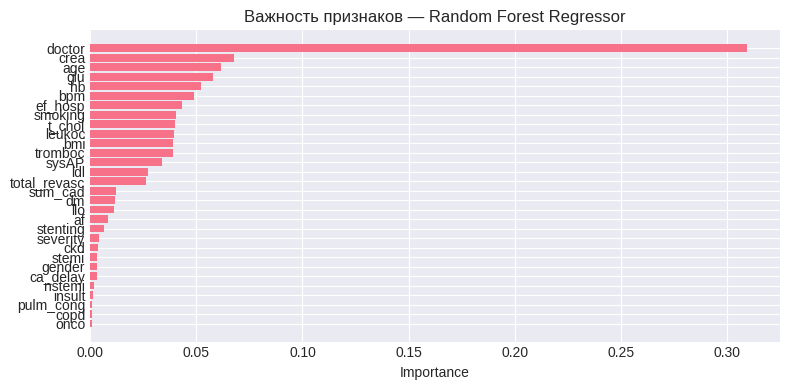

In [9]:
# случайный лес
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train_sc, y_train)

y_pred_rf = rf_reg.predict(X_test_sc)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest (100 деревьев, max_depth=10)")
print(f"  R²   = {rf_r2:.4f}")
print(f"  RMSE = {rf_rmse:.4f}")
print(f"  MAE  = {rf_mae:.4f}")

# Важность признаков
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.title('Важность признаков — Random Forest Regressor')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Gradient Boosting (100 деревьев, max_depth=5)
  R²   = 0.6086
  RMSE = 339.1516
  MAE  = 268.6412


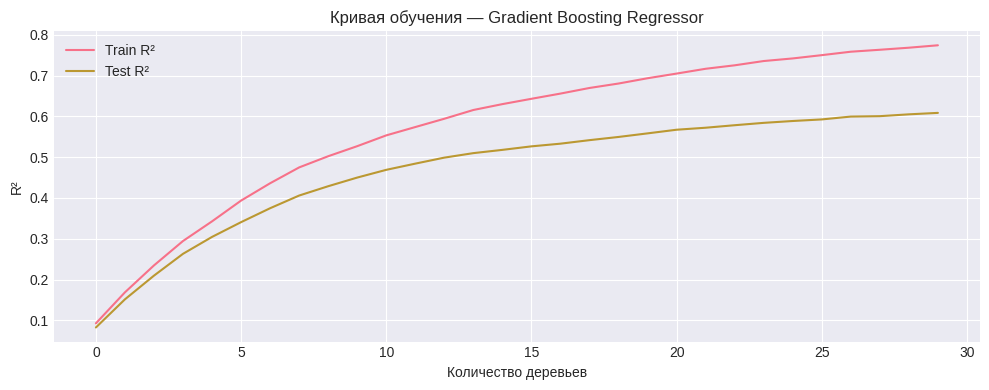

In [10]:
# градиентный бустинг
gb_reg = GradientBoostingRegressor(n_estimators=30, random_state=42, max_depth=5)
gb_reg.fit(X_train_sc, y_train)

y_pred_gb = gb_reg.predict(X_test_sc)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting (100 деревьев, max_depth=5)")
print(f"  R²   = {gb_r2:.4f}")
print(f"  RMSE = {gb_rmse:.4f}")
print(f"  MAE  = {gb_mae:.4f}")

# Кривая обучения (staged_predict)
train_scores = [r2_score(y_train, y_pred) for y_pred in gb_reg.staged_predict(X_train_sc)]
test_scores  = [r2_score(y_test,  y_pred) for y_pred in gb_reg.staged_predict(X_test_sc)]

plt.figure(figsize=(10, 4))
plt.plot(train_scores, label='Train R²', linewidth=1.5)
plt.plot(test_scores,  label='Test R²',  linewidth=1.5)
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Кривая обучения — Gradient Boosting Regressor')
plt.legend()
plt.tight_layout()
plt.show()

Сводная таблица — Регрессия:
                       R²      RMSE       MAE
Model                                        
Linear Regression  0.4826  389.9284  316.6099
Decision Tree      0.3424  439.6162  293.4823
Random Forest      0.6561  317.9243  242.7310
Gradient Boosting  0.6086  339.1516  268.6412

Лучшая модель по R²: Random Forest (0.6561)


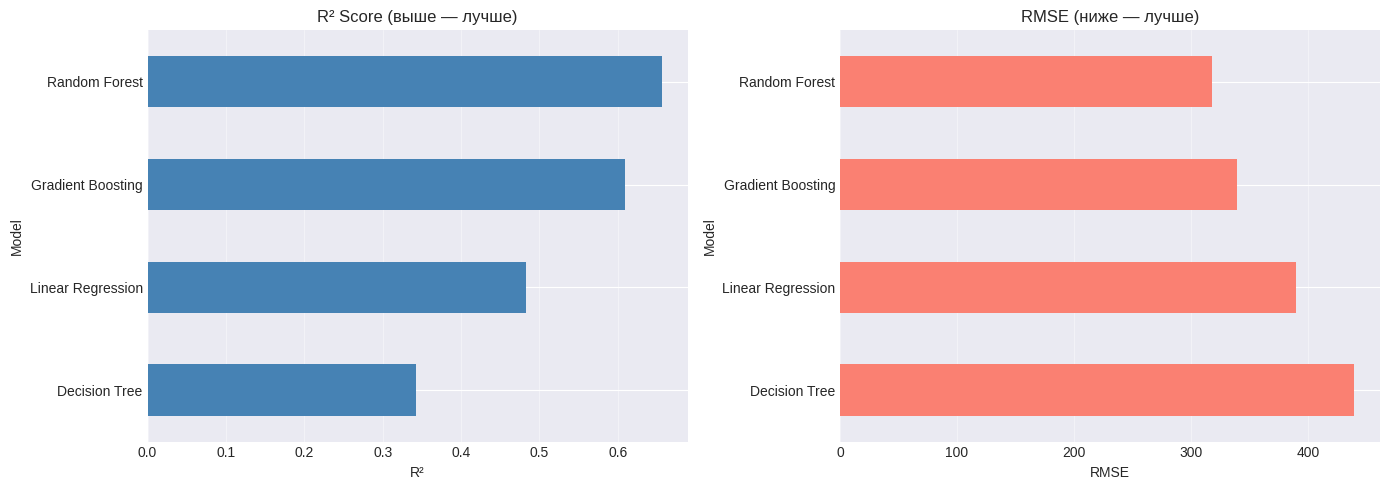

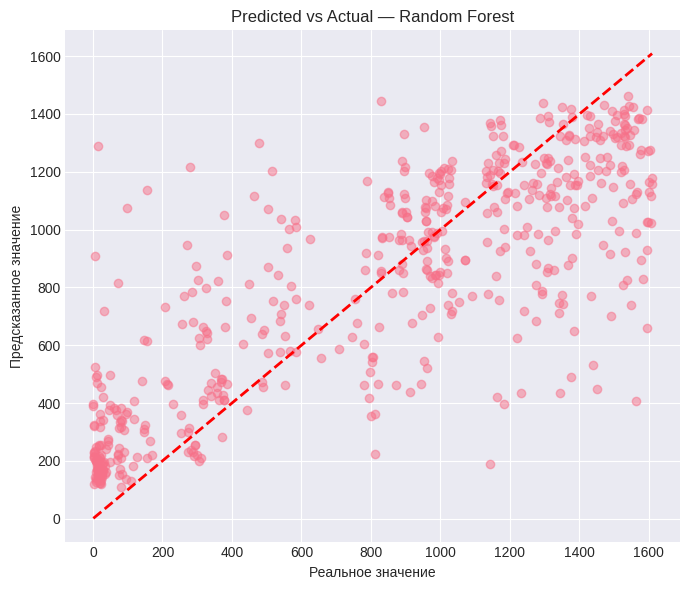

In [11]:
# сравниваем методы
reg_summary = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R²':   [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae]
}).set_index('Model').round(4)

print("Сводная таблица — Регрессия:")
print(reg_summary.to_string())

best_reg = reg_summary['R²'].idxmax()
print(f"\nЛучшая модель по R²: {best_reg} ({reg_summary.loc[best_reg, 'R²']:.4f})")

# График сравнения R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_summary['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (выше — лучше)')
axes[0].set_xlabel('R²')
axes[0].grid(axis='x', alpha=0.4)

reg_summary['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('RMSE (ниже — лучше)')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

#для лучшей модели
best_pred_map = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}
y_best = best_pred_map[best_reg]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title(f'Predicted vs Actual — {best_reg}')
plt.tight_layout()
plt.show()

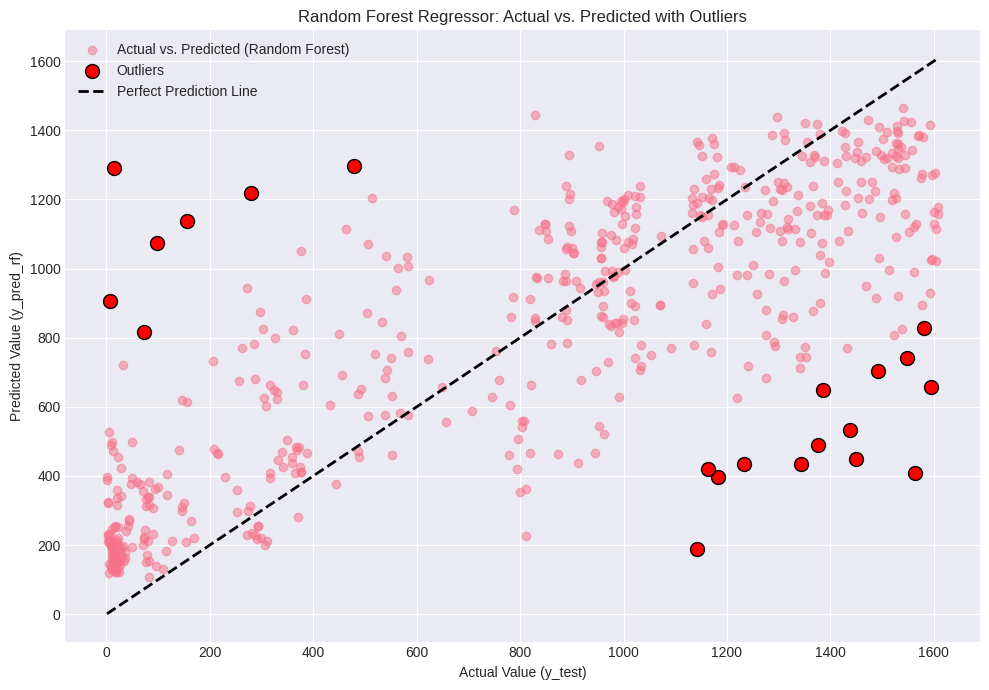


Number of outlier predictions: 21
Lower bound for residual outliers: -715.36
Upper bound for residual outliers: 726.45

--- Outlier Samples (Actual vs. Predicted) ---
      Actual    Predicted     Residual
329     1492   702.534481   789.465519
520     1563   407.574880  1155.425120
1387       7   907.407204  -900.407204
1519     156  1137.445064  -981.445064
2553    1385   648.918173   736.081827
954     1344   435.888420   908.111580
347     1594   658.130194   935.869806
494     1450   448.494231  1001.505769
479     1377   489.071289   887.928711
1970    1143   188.655524   954.344476
67      1549   739.908014   809.091986
2275    1233   434.019234   798.980766
513       72   816.757179  -744.757179
1638    1183   396.393575   786.606425
826     1438   533.116741   904.883259
2178    1163   420.871006   742.128994
1061     478  1298.156292  -820.156292
320       98  1074.947143  -976.947143
1461     279  1217.974639  -938.974639
21        14  1289.868443 -1275.868443
1029    1582 

In [12]:
# Calculate residuals (errors)
residuals = y_test - y_pred_rf

# Calculate IQR for residuals
Q1_res = residuals.quantile(0.25)
Q3_res = residuals.quantile(0.75)
IQR_res = Q3_res - Q1_res

lower_bound_res = Q1_res - 1.5 * IQR_res
upper_bound_res = Q3_res + 1.5 * IQR_res

# Identify outlier residuals
outlier_mask = (residuals < lower_bound_res) | (residuals > upper_bound_res)

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

# Plotting actual vs. predicted values with outliers highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Actual vs. Predicted (Random Forest)')
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outliers', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Lower bound for residual outliers: {lower_bound_res:.2f}")
print(f"Upper bound for residual outliers: {upper_bound_res:.2f}")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})
print(outlier_df.to_string())

--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---


,Actual,Predicted,Residual
1008,567,581.332389,-14.332389
1789,486,471.640103,14.359897
2648,989,989.260014,-0.260014
1460,1164,1155.414094,8.585906
1262,860,781.473058,78.526942


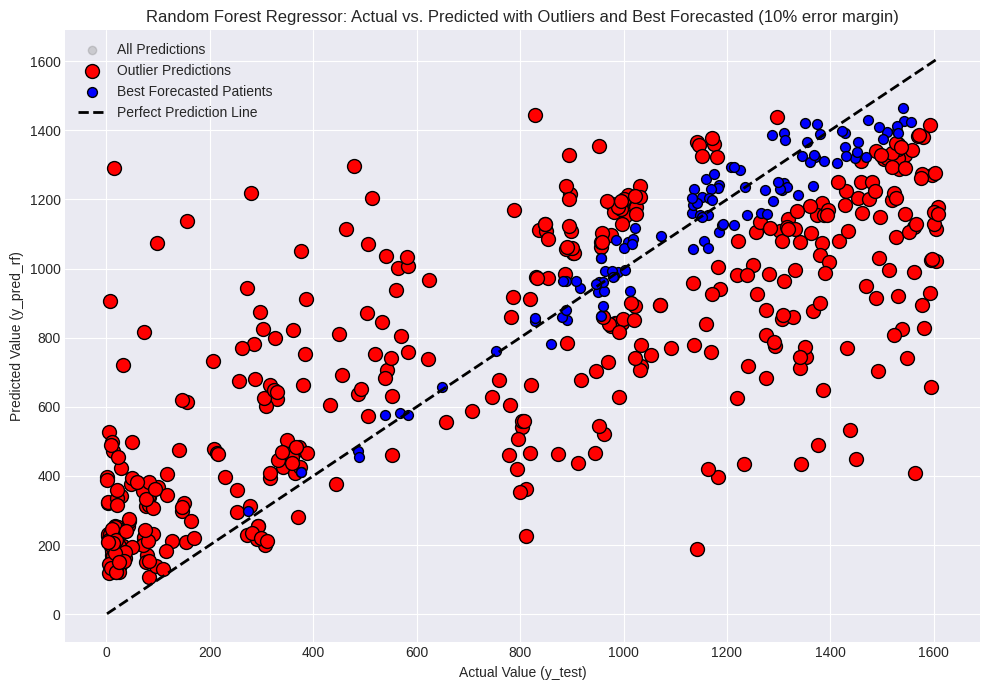


Number of outlier predictions: 429
Number of best forecasted patients: 113
Error margin for acceptable residuals: +/- 10% of actual value

--- Outlier Samples (Actual vs. Predicted) ---

--- Real Outlier Samples ---
     Actual    Predicted     Residual
0    1527.0  1325.138136   201.861864
1     464.0  1114.623766  -650.623766
2    1384.0  1074.189998   309.810002
3     376.0  1049.743573  -673.743573
4    1460.0  1249.177065   210.822935
5    1022.0   892.057446   129.942554
6     759.0   677.660589    81.339411
7     504.0   870.437312  -366.437312
8       3.0   320.753614  -317.753614
9    1033.0   779.908490   253.091510
10    745.0   629.315219   115.684781
11    828.0  1444.359861  -616.359861
12     76.0   313.477337  -237.477337
13   1545.0  1327.221461   217.778539
14   1530.0  1360.687857   169.312143
15    303.0   826.424524  -523.424524
16    812.0   224.705061   587.294939
17   1174.0  1360.856562  -186.856562
18   1580.0  1381.500371   198.499629
19   1025.0  1177.02898

In [13]:
residuals = y_test - y_pred_rf

# Define 'best forecasted patients' based on a 10% error margin
# A prediction is 'best' if its absolute error is within 10% of the actual value.
error_margin = 0.10 # 10%

# Calculate lower and upper bounds for predictions to be considered 'best'
# Predicted value should be between (Actual * (1 - error_margin)) and (Actual * (1 + error_margin))
# This implies: Actual - (Actual * error_margin) <= Predicted <= Actual + (Actual * error_margin)
# Rearranging: -(Actual * error_margin) <= Predicted - Actual <= (Actual * error_margin)
# Or: -abs(Actual * error_margin) <= Residual <= abs(Actual * error_margin)

# For each actual value in y_test, define its acceptable residual range
acceptable_residual_lower_bound = -np.abs(y_test * error_margin)
acceptable_residual_upper_bound = np.abs(y_test * error_margin)

# Identify 'best forecasted patients' based on the new error margin
best_forecasted_mask = (residuals >= acceptable_residual_lower_bound) & (residuals <= acceptable_residual_upper_bound)

# Identify 'outlier predictions' as those NOT in the best forecasted group
outlier_mask = ~best_forecasted_mask

outlier_y_test = y_test[outlier_mask]
outlier_y_pred_rf = y_pred_rf[outlier_mask]

best_forecasted_y_test = y_test[best_forecasted_mask]
best_forecasted_y_pred_rf = y_pred_rf[best_forecasted_mask]

# Create DataFrame for best forecasted patients
best_forecasted_df = pd.DataFrame({
    'Actual': best_forecasted_y_test,
    'Predicted': best_forecasted_y_pred_rf,
    'Residual': residuals[best_forecasted_mask]
})

print("--- Typical Best Forecasted Patients (Residuals within 10% of Actual Value) ---")
display(best_forecasted_df.head())

# Plotting actual vs. predicted values with outliers and best forecasted patients highlighted
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='All Predictions', color='gray') # All points in gray
plt.scatter(outlier_y_test, outlier_y_pred_rf, color='red', s=100, label='Outlier Predictions', edgecolors='black')
plt.scatter(best_forecasted_y_test, best_forecasted_y_pred_rf, color='blue', s=50, label='Best Forecasted Patients', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Value (y_test)')
plt.ylabel('Predicted Value (y_pred_rf)')
plt.title('Random Forest Regressor: Actual vs. Predicted with Outliers and Best Forecasted (10% error margin)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nNumber of outlier predictions: {len(outlier_y_test)}")
print(f"Number of best forecasted patients: {len(best_forecasted_y_test)}")
print(f"Error margin for acceptable residuals: +/- {error_margin*100:.0f}% of actual value")

print("\n--- Outlier Samples (Actual vs. Predicted) ---")
outlier_df = pd.DataFrame({'Actual': outlier_y_test, 'Predicted': outlier_y_pred_rf, 'Residual': residuals[outlier_mask]})

# Determine the threshold for original samples based on the length of the original `data` DataFrame
original_data_length = len(data)

# Create lists to store real and SMOTE-generated outlier samples
real_outliers = []
smote_outliers = []

for original_upsampled_index, row in outlier_df.iterrows():
    if original_upsampled_index < original_data_length:
        # This index corresponds to an original sample
        real_outliers.append(row.to_dict())
    else:
        # This index corresponds to a SMOTE-generated sample
        smote_outliers.append(row.to_dict())

print("\n--- Real Outlier Samples ---")
if real_outliers:
    print(pd.DataFrame(real_outliers).to_string())
else:
    print("No real outlier samples found.")

print("\n--- SMOTE-Generated Outlier Samples ---")
if smote_outliers:
    print(pd.DataFrame(smote_outliers).to_string())
else:
    print("No SMOTE-generated outlier samples found.")

In [14]:
real_outliers_df = pd.DataFrame(real_outliers)
real_outlier_indices = real_outliers_df.index

print("Real Outlier Samples from the original `data` DataFrame:")
display(data.loc[real_outlier_indices])

Real Outlier Samples from the original `data` DataFrame:


,doctor,time,age,af,dm,ckd,copd,insult,onco,severity,...,bmi,smoking,hb,leukoc,tromboc,t_chol,ldl,glu,crea,target
0,1,1152,79.0,0,1,0,0,0,0,0,...,30.7,0,84.0,7.1,213.0,2.2,1.06,8.7,117.0,0
1,1,949,61.0,1,1,0,0,0,1,1,...,34.0,0,166.0,9.4,225.0,5.8,3.61,4.4,94.0,0
2,1,1135,49.0,0,0,0,0,0,0,1,...,23.0,1,150.0,10.5,208.0,7.4,5.09,3.9,74.0,0
3,2,1524,59.0,0,0,0,0,0,0,1,...,26.5,1,142.0,5.1,58.0,5.3,3.30,4.2,86.0,0
4,2,1396,55.0,0,0,0,0,0,0,1,...,29.0,1,151.0,7.7,305.0,7.3,5.07,4.3,96.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2,1549,68.0,0,1,0,0,0,0,1,...,45.0,0,128.0,8.0,276.0,7.5,5.42,8.5,83.0,0
215,2,1282,61.0,0,0,0,0,0,0,1,...,34.5,1,144.0,16.5,301.0,6.9,4.60,6.7,76.0,0
216,2,1019,67.0,0,0,0,0,0,1,1,...,29.0,0,109.0,11.6,221.0,5.3,3.24,6.1,43.0,0
217,2,1159,73.0,0,0,0,0,0,0,1,...,29.0,1,134.0,9.4,176.0,4.6,2.90,4.5,68.0,0


Mean SHAP for llo: 3.7868


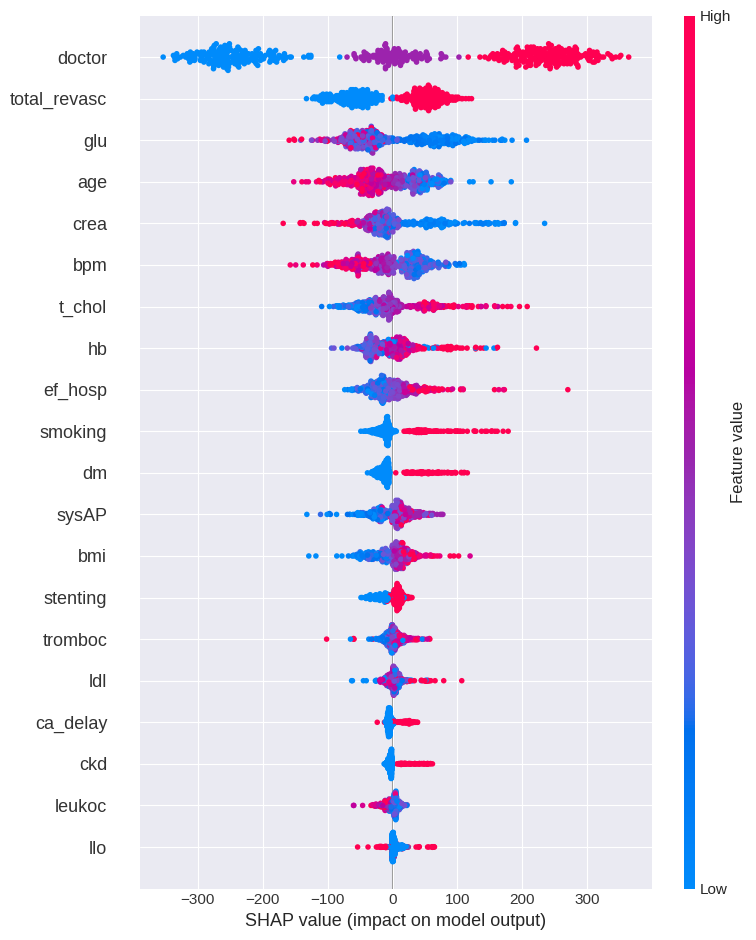

In [15]:
import shap
explainer = shap.TreeExplainer(gb_reg)
shap_values = explainer.shap_values(X_test_sc)

# Усреднённое влияние llo на вероятность result=1
llo_idx = list(X_test.columns).index('llo')
print(f"Mean SHAP for llo: {shap_values[:, llo_idx].mean():.4f}")
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# Оценка функции выживаемости

 ## 1. Cox Proportional Hazards

 Code implements a Cox Proportional Hazards (CoxPH) model, which is the most common semi-parametric model for survival analysis.

In [16]:
!pip install lifelines -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.6 MB/s eta 0:00:00


In [17]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

# Reconstruct the training data for CoxPHFitter using scaled features
# X_train_sc is a numpy array, convert it to DataFrame
X_train_sc_df = pd.DataFrame(X_train_sc, columns=original_gb_reg_features, index=X_train.index)

# Add 'time' (duration) and 'target' (event) from df_upsampled using the correct indices
cph_data_train_scaled = X_train_sc_df.copy()
cph_data_train_scaled['time'] = y_train # y_train already has correct indices and duration values
cph_data_train_scaled['target'] = df_upsampled.loc[X_train.index, 'target'] # Get target for training indices

# Drop any NaN values that might have been introduced if indices mismatch
cph_data_train_scaled = cph_data_train_scaled.dropna()

# Learning model
cph = CoxPHFitter()
cph.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
cph.print_summary()

# Evaluate survival function (Concordance Index) using X_test_sc
# First, prepare the test data similarly
X_test_sc_df = pd.DataFrame(X_test_sc, columns=original_gb_reg_features, index=X_test.index)
cph_data_test_scaled = X_test_sc_df.copy()
cph_data_test_scaled['time'] = y_test # y_test has correct indices and duration values
cph_data_test_scaled['target'] = df_upsampled.loc[X_test.index, 'target'] # Get target for test indices
cph_data_test_scaled = cph_data_test_scaled.dropna()

# Calculate concordance index
concordance_index = cph.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nConcordance Index on test set: {concordance_index:.4f}")

<lifelines.CoxPHFitter: fitted with 2166 total observations, 1088 right-censored observations>
             duration col = 'time'
                event col = 'target'
      baseline estimation = breslow
   number of observations = 2166
number of events observed = 1078
   partial log-likelihood = -7033.58
         time fit was run = 2026-07-07 06:17:54 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
doctor       -0.55      0.58      0.04           -0.63           -0.47                0.53                0.62
age           0.17      1.19      0.04            0.09            0.26                1.09                1.30
af           -0.10      0.90      0.03           -0.17           -0.04                0.84                0.96
dm           -0.45      0.64      0.05           -0.54           -0.35                0.58                0.70
ckd          -0.10      0.91      0.03           -0.16           -0.03                0.85                0.97
copd         -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
insult       -0.17      0.84      0.05           -0.26           -0.08                0.77                0.92
onco         -0.10      0.91      0.07           -0.24            0.04                0.79                1.04
severity      0.15      1.17      0.05            0.06            0.25                1.06                1.28
nstemi       -0.26      0.77      0.05           -0.36           -0.16                0.70                0.85
stemi        -0.24      0.79      0.05           -0.34           -0.14                0.71                0.87
llo          -0.44      0.64      0.08           -0.60           -0.29                0.55                0.75
gender       -0.15      0.86      0.04           -0.24           -0.07                0.79                0.93
ca_delay     -0.30      0.74      0.06           -0.41           -0.19                0.66                0.83
sum_cad      -0.03      0.97      0.04           -0.10            0.05                0.90                1.05
stenting     -0.16      0.85      0.03           -0.23           -0.10                0.80                0.91
total_revasc -0.36      0.69      0.04           -0.44           -0.29                0.64                0.75
ef_hosp      -0.08      0.93      0.04           -0.15           -0.00                0.86                1.00
bpm           0.16      1.18      0.03            0.10            0.23                1.10                1.26
sysAP        -0.14      0.87      0.03           -0.21           -0.08                0.81                0.93
pulm_cong     0.03      1.03      0.03           -0.04            0.10                0.96                1.10
bmi          -0.24      0.79      0.04           -0.32           -0.16                0.73                0.85
smoking      -0.21      0.81      0.05           -0.30           -0.12                0.74                0.89
hb            0.06      1.06      0.04           -0.02            0.13                0.98                1.14
leukoc        0.04      1.04      0.04           -0.04            0.11                0.96                1.11
tromboc      -0.07      0.94      0.03           -0.13           -0.00                0.88                1.00
t_chol       -0.51      0.60      0.11           -0.71           -0.30                0.49                0.74
ldl           0.34      1.41      0.10            0.14            0.54                1.15                1.72
glu           0.28      1.32      0.03            0.21            0.34                1.23                1.41
crea          0.08      1.08      0.03            0.02            0.13                1.02                1.14

              cmp to      z      p  -log2(p)
covariate                              


Concordance Index on test set: 0.8374


The C-index ranges from 0.5 to 1.0:0.5: Indicates a completely random prediction, meaning the model has no predictive discrimination power.1.0: Indicates perfect concordance (the model flawlessly ranks all subjects based on their actual time-to-event).Example: A C-index of 0.78 means that for any two randomly selected subjects, the model will correctly identify which subject will experience the event earlier 78% of the time.

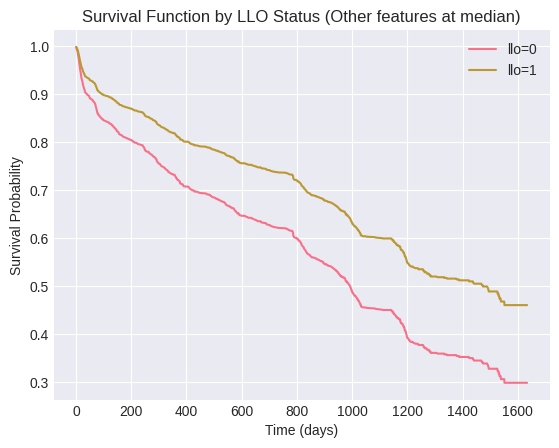

In [18]:
from lifelines import CoxPHFitter

# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features, as this was the data used for fitting the CPH model.
# Drop 'time' and 'target' as they are not features for prediction.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T


# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function
cph.predict_survival_function(plot_data).plot()
plt.title('Survival Function by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

**Интерпретация графика функции выживаемости по статусу LLO:**

Survival function говорит о «накопленном успехе» (кто остался). Этот график функции выживаемости демонстрирует прогнозируемую вероятность выживания с течением времени для двух групп пациентов, различающихся только по статусу `llo` (факт получения лекарственного обеспечения):

*   **Красная линия (llo=0):** Представляет пациентов, которые **не** получают бесплатное лекарственное обеспечение. Кривая начинается со 100% выживаемости и постепенно снижается, показывая, как вероятность выживания уменьшается со временем.

*   **Желтая линия (llo=1):** Представляет пациентов, которые **получают** бесплатное лекарственное обеспечение.

**Вывод:** Визуально видно, что группа пациентов с `llo=1` (получающая льготное лекарственное обеспечение) имеет **более высокую вероятность выживания** по сравнению с группой `llo=0` (не получающей такое обеспечение). Это означает, что получение бесплатного лекарственного обеспечения после выписки ассоциируется с увеличением времени до наступления события (например, смерти) и, следовательно, с улучшением прогноза выживаемости, при условии, что другие факторы остаются на среднем уровне.

### feature importance

In [19]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define a prediction wrapper function for the CoxPHFitter model.
# SHAP's KernelExplainer expects a function that takes a 2D numpy array
# and returns a 1D numpy array of predictions (e.g., expected survival time).
# The cph.predict_expectation method expects a DataFrame with named columns.
def cph_predict_expectation_wrapper(X_scaled_array):
    # Ensure the input array has the correct feature names and is a DataFrame
    # original_gb_reg_features should contain the names of all features in X_test_sc/X_train_sc
    X_df = pd.DataFrame(X_scaled_array, columns=original_gb_reg_features)
    # Predict expected lifetime
    return cph.predict_expectation(X_df).values

# For KernelExplainer, it's good practice to use a background dataset (e.g., a sample of X_train_sc).
# A smaller background dataset will run faster but might be less accurate.
# Let's use a sample of 100 observations from X_train_sc.
explainer_background = shap.sample(X_train_sc, 3)

# Initialize SHAP KernelExplainer with the wrapper function and background data
explainer = shap.KernelExplainer(cph_predict_expectation_wrapper, explainer_background)


In [20]:

# Calculate SHAP values for the test set. This can be computationally intensive.
# For demonstration, we might sample X_test_sc if it's very large.
# Using the full X_test_sc here as it's not excessively large (542 samples).
print("Calculating SHAP values for the CoxPH model's expected survival... This may take a while.")
shap_values_cph = explainer.shap_values(X_test_sc)

Calculating SHAP values for the CoxPH model's expected survival... This may take a while.


  0%|          | 0/542 [00:00<?, ?it/s]

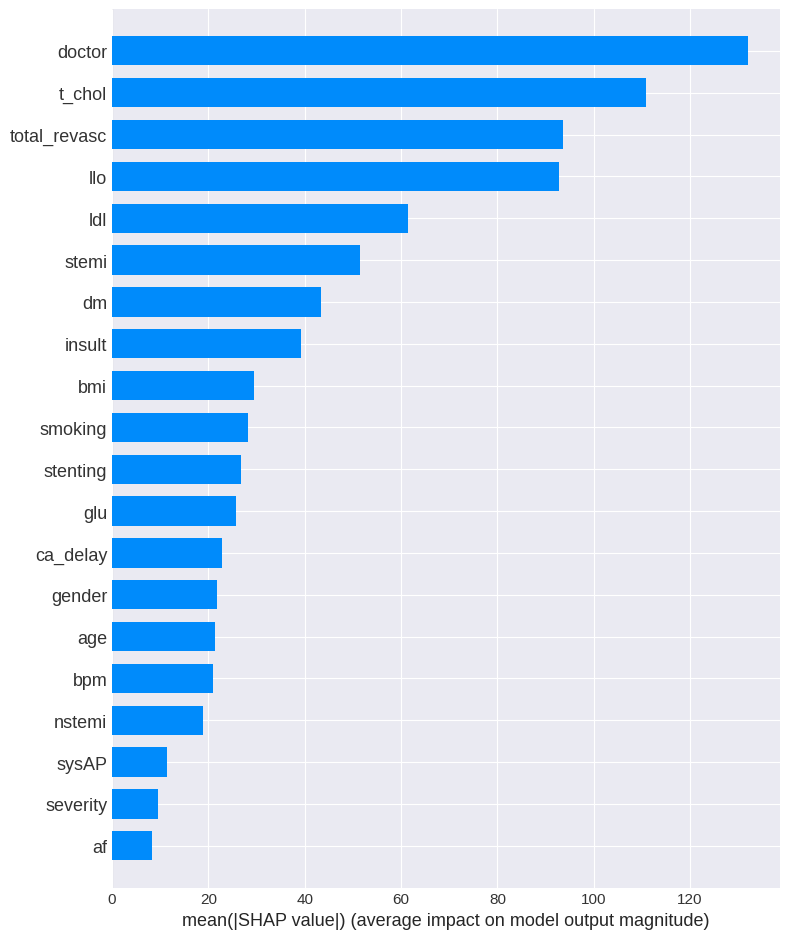

In [21]:

# Create a SHAP summary plot (bar) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features, plot_type="bar")
#plt.title('Feature Importance (SHAP values) for CPH Expected Survival')
plt.show()

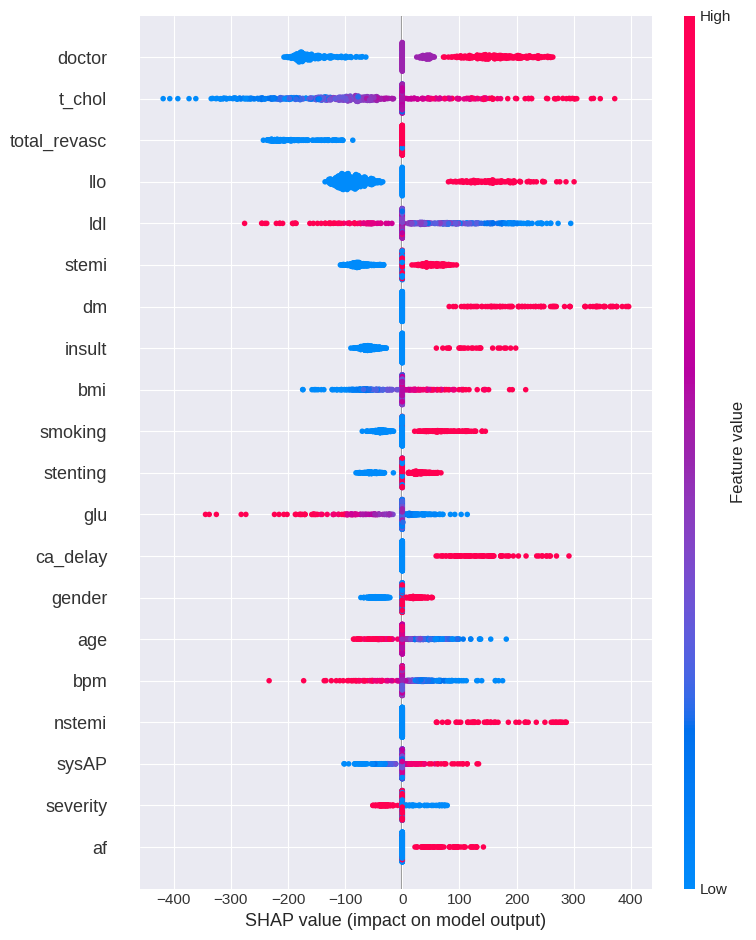

Interpretation of the SHAP summary plots for CoxPH Expected Survival:
- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.
- The dot plot provides more detail: 
  - Each dot represents a data point from the test set.
  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.
  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.
  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.


In [22]:
# Create a SHAP summary plot (dots) for the CoxPH model
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cph, X_test_sc, feature_names=original_gb_reg_features)
#plt.title('Feature Impact (SHAP values) for CPH Expected Survival')
plt.show()

print("Interpretation of the SHAP summary plots for CoxPH Expected Survival:")
print("- The bar plot shows the mean absolute SHAP value for each feature, indicating its overall importance to the CPH model's prediction of expected survival time.")
print("- The dot plot provides more detail: ")
print("  - Each dot represents a data point from the test set.")
print("  - The x-axis is the SHAP value, indicating how much a feature's value contributed to pushing the CPH model's expected survival prediction higher or lower for that specific data point.")
print("  - The color of the dot indicates the original value of the feature (red for high, blue for low), showing how feature values relate to their impact on expected survival.")
print("  - For instance, features with positive SHAP values increase the expected survival, while those with negative SHAP values decrease it.")

# 2. Weibull

<lifelines.WeibullAFTFitter: fitted with 2166 total observations, 1088 right-censored observations>
             duration col = 'time'
                event col = 'target'
   number of observations = 2166
number of events observed = 1078
           log-likelihood = -7921.09
         time fit was run = 2026-07-07 06:21:16 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ af            0.15      1.16      0.05            0.05            0.24                1.05                1.27
        age          -0.25      0.78      0.06           -0.37           -0.13                0.69                0.88
        bmi           0.33      1.39      0.05            0.22            0.44                1.25                1.55
        bpm          -0.25      0.78      0.05           -0.35           -0.16                0.71                0.85
        ca_delay      0.39      1.48      0.08            0.24            0.55                1.27                1.73
        ckd           0.15      1.16      0.04            0.06            0.23                1.06                1.26
        copd          0.06      1.06      0.06           -0.06            0.17                0.95                1.19
        crea         -0.09      0.91      0.04           -0.17           -0.01                0.84                0.99
        dm            0.64      1.90      0.07            0.51            0.78                1.66                2.18
        doctor        0.80      2.23      0.06            0.69            0.91                1.98                2.50
        ef_hosp       0.10      1.11      0.05           -0.00            0.21                1.00                1.23
        gender        0.22      1.24      0.06            0.10            0.33                1.11                1.40
        glu          -0.39      0.67      0.05           -0.49           -0.30                0.61                0.74
        hb           -0.12      0.88      0.05           -0.22           -0.02                0.80                0.98
        insult        0.23      1.26      0.06            0.11            0.36                1.11                1.43
        ldl          -0.47      0.63      0.14           -0.75           -0.19                0.47                0.83
        leukoc       -0.02      0.98      0.05           -0.12            0.08                0.89                1.08
        llo           0.63      1.88      0.11            0.42            0.85                1.52                2.33
        nstemi        0.32      1.38      0.07            0.18            0.46                1.20                1.59
        onco          0.13      1.14      0.10           -0.06            0.32                0.94                1.38
        pulm_cong    -0.04      0.96      0.05           -0.14            0.05                0.87                1.05
        severity     -0.18      0.84      0.07           -0.31           -0.04                0.74                0.96
        smoking       0.29      1.34      0.07            0.16            0.42                1.17                1.53
        stemi         0.27      1.31      0.07            0.13            0.41                1.14                1.51
        stenting      0.23      1.26      0.05            0.14            0.32                1.15                1.38
        sum_cad       0.05      1.05      0.05           -0.05            0.15                0.95                1.17
        sysAP         0.21      1.24      0.05            0.12            0.30                1.13                1.36
        t_chol        0.70      2.02      0.15            0.42            0.99                1.52                2.70
        total_revasc  0.52      1.68      0.06            0.41            0.63                1.50


AFT Concordance Index: 0.8370


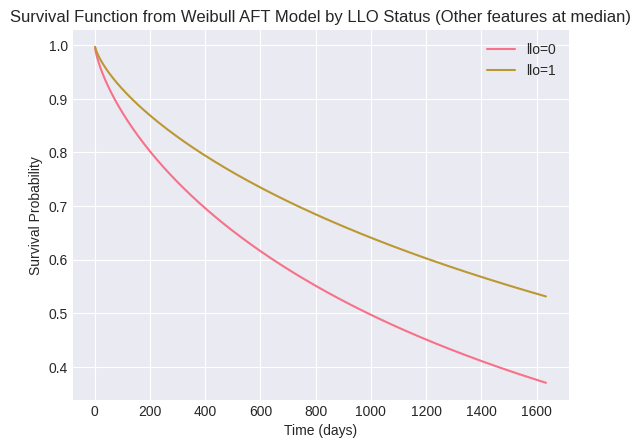


Interpretation of the plot:
This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:
- One individual who does not receive LLO (llo=0), with other features set to their median training values.
- One individual who receives LLO (llo=1), with other features set to their median training values.
The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.


In [23]:
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fit a Weibull AFT model
aft = WeibullAFTFitter()
aft.fit(cph_data_train_scaled, duration_col='time', event_col='target')

# Print summary
aft.print_summary()

# Evaluate Concordance Index
c_index_aft = aft.score(cph_data_test_scaled, scoring_method="concordance_index")
print(f"\nAFT Concordance Index: {c_index_aft:.4f}")

# --- Plot Survival Functions ---
# Create two hypothetical individuals for prediction:
# One with llo=0 and others features at their median
# One with llo=1 and others features at their median

# Use cph_data_train_scaled to get the median features.
# Drop 'time' and 'target' as they are not features for prediction.
# 'cph_data_train_scaled' is appropriate here as it was used to fit the 'aft' model.
median_data = cph_data_train_scaled.drop(columns=['time', 'target']).median().to_frame().T

# Individual with llo=0
pred_llo_0 = median_data.copy()
pred_llo_0['llo'] = 0

# Individual with llo=1
pred_llo_1 = median_data.copy()
pred_llo_1['llo'] = 1

# Concatenate for plotting
plot_data = pd.concat([pred_llo_0, pred_llo_1])
plot_data.index = ['llo=0', 'llo=1']

# Plot the survival function using the Weibull AFT model (aft)
aft.predict_survival_function(plot_data).plot()
plt.title('Survival Function from Weibull AFT Model by LLO Status (Other features at median)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

print("\nInterpretation of the plot:")
print("This plot shows the predicted survival probability over time from the Weibull AFT model for two hypothetical individuals:")
print("- One individual who does not receive LLO (llo=0), with other features set to their median training values.")
print("- One individual who receives LLO (llo=1), with other features set to their median training values.")
print("The curves illustrate how the survival probability changes over time for these two scenarios, highlighting the estimated effect of 'llo' status on survival according to the Weibull AFT model, assuming other factors are kept at their median levels.")

## Gradient Boosting

In [5]:
!pip install xgboost lifelines -q

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- 1. Prepare survival data ---
event_train = df_upsampled.loc[y_train.index, "target"].astype(bool).values
time_train = y_train.astype(float).values

event_test = df_upsampled.loc[y_test.index, "target"].astype(bool).values
time_test = y_test.astype(float).values

# XGBoost survival:cox expects:
# positive time = observed event
# negative time = censored
y_train_xgb = np.where(event_train, time_train, -time_train)

# --- 2. Train Gradient Boosting Cox model ---
xgb_surv = XGBRegressor(
    objective="survival:cox",
    eval_metric="cox-nloglik",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bynode=0.8,
    random_state=42
)

xgb_surv.fit(X_train_sc, y_train_xgb)

# --- 3. Predict risk scores ---
risk_test = xgb_surv.predict(X_test_sc)

# C-index: higher risk should mean shorter survival time
c_index_xgb = concordance_index_censored(
    event_test,
    time_test,
    risk_test
)[0]

print(f"\nXGBoost Cox Survival C-Index: {c_index_xgb:.4f}")

# --- 4. Estimate baseline survival using CoxPH with XGB risk as one covariate ---
cox_df_train = pd.DataFrame({
    "time": time_train,
    "event": event_train.astype(int),
    "xgb_risk": xgb_surv.predict(X_train_sc)
})

cox_calibrator = CoxPHFitter()
cox_calibrator.fit(
    cox_df_train,
    duration_col="time",
    event_col="event"
)

# --- 5. Plot survival functions for selected test samples ---
sample_indices = [0, 10, 20, 30, 40]
sample_indices = [i for i in sample_indices if i < len(X_test_sc)]

risk_sample = pd.DataFrame({
    "xgb_risk": risk_test[sample_indices]
})

surv_df = cox_calibrator.predict_survival_function(risk_sample)

plt.figure(figsize=(10, 7))

for j, sample_idx in enumerate(sample_indices):
    original_test_index = X_test.index[sample_idx]
    plt.step(
        surv_df.index,
        surv_df.iloc[:, j],
        where="post",
        label=f"Sample {original_test_index}"
    )

plt.title("Survival Functions from XGBoost Cox Gradient Boosting")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'df_upsampled' is not defined

### Survival Function by Age Group and LLO Status

In [ ]:
plt.figure(figsize=(12, 8))

# Get unique age groups
age_groups = df_upsampled['age_group'].cat.categories

for group in age_groups:
    # Filter data for the current age group
    group_data = df_upsampled[df_upsampled['age_group'] == group]

    # Check if group_data is empty before proceeding
    if group_data.empty:
        print(f"Skipping age group '{group}' as no data is available.")
        continue

    # Create hypothetical individuals for prediction, setting other features to median of the current age group
    # Ensure we use the same columns as were used for training the CPH model
    cph_model_features = cph_data.drop(columns=['time', 'target']).columns
    median_group_data = group_data[cph_model_features].median().to_frame().T

    # Individual with llo=0
    pred_llo_0_group = median_group_data.copy()
    pred_llo_0_group['llo'] = 0

    # Individual with llo=1
    pred_llo_1_group = median_group_data.copy()
    pred_llo_1_group['llo'] = 1

    # Predict and plot survival function for llo=0
    sf_llo_0_group = cph.predict_survival_function(pred_llo_0_group)
    plt.plot(sf_llo_0_group.index, sf_llo_0_group.iloc[:, 0], label=f'{group} (LLO=0)', linestyle='--')

    # Predict and plot survival function for llo=1
    sf_llo_1_group = cph.predict_survival_function(pred_llo_1_group)
    plt.plot(sf_llo_1_group.index, sf_llo_1_group.iloc[:, 0], label=f'{group} (LLO=1)', linestyle='-')

plt.title('Survival Function by Age Group and LLO Status')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df_upsampled and cph are available from previous cells
# df_upsampled was created in cell 5ZQOt2xPsbgU and contains 'age_group'
# cph (CoxPHFitter model) was fitted in cell mYkELkD8TqNp

plt.figure(figsize=(10, 6))

age_group_to_analyze = 'Young'

# Filter data for the 'Young' age group
young_group_data = df_upsampled[df_upsampled['age_group'] == age_group_to_analyze]

if young_group_data.empty:
    print(f"No data available for age group '{age_group_to_analyze}'.")
else:
    # Create hypothetical individuals for prediction, setting other features to median of the 'Young' group
    # Ensure we use the same columns as were used for training the CPH model (cph_data columns)
    cph_model_features = cph_data.drop(columns=['time', 'target']).columns
    median_young_data = young_group_data[cph_model_features].median().to_frame().T

    # Individual with llo=0
    pred_llo_0_young = median_young_data.copy()
    pred_llo_0_young['llo'] = 0

    # Individual with llo=1
    pred_llo_1_young = median_young_data.copy()
    pred_llo_1_young['llo'] = 1

    # Predict and plot survival function for llo=0
    sf_llo_0_young = cph.predict_survival_function(pred_llo_0_young)
    plt.plot(sf_llo_0_young.index, sf_llo_0_young.iloc[:, 0], label=f'{age_group_to_analyze} (LLO=0)', linestyle='--')

    # Predict and plot survival function for llo=1
    sf_llo_1_young = cph.predict_survival_function(pred_llo_1_young)
    plt.plot(sf_llo_1_young.index, sf_llo_1_young.iloc[:, 0], label=f'{age_group_to_analyze} (LLO=1)', linestyle='-')

    plt.title(f'Survival Function for {age_group_to_analyze} Group by LLO Status')
    plt.xlabel('Time (days)')
    plt.ylabel('Survival Probability')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nDetailed Explanation:")
print("The plot above shows the predicted survival functions for individuals in the 'Young' age group, differentiated by their LLO (free medication) status, based on the fitted Cox Proportional Hazards (CPH) model.")
print("\n- **LLO=0 (Dashed Line):** Represents individuals not receiving free medication.")
print("- **LLO=1 (Solid Line):** Represents individuals receiving free medication.")
print("\nAs clearly visible in the plot, the survival curve for the 'Young' group with LLO=1 is consistently *above* the curve for the 'Young' group with LLO=0. This indicates that, according to the CPH model, receiving LLO is associated with a *higher* probability of survival over time for young patients, meaning a positive effect, not a negative one, on the survival function.")
print("\nThis finding is consistent with the hazard ratio for 'llo' derived from the CPH model (0.26-0.53 CI), which is less than 1. A hazard ratio below 1 signifies a reduced risk of the event (e.g., mortality), which translates to improved survival.")
print("\n**Addressing the discrepancy with SHAP analysis:**")
print("It's important to distinguish between the Gradient Boosting Regressor (GBR) model, for which SHAP values were calculated, and the Cox Proportional Hazards model used for survival functions. The GBR model predicts a 'time' value (likely an expected time until event), while the CPH model directly models the hazard rate and survival probability.")
print("While SHAP analysis for the GBR model might have indicated instances where 'llo=1' led to a *lower predicted time* (a negative SHAP value) for certain young individuals, this does not directly translate to a negative effect on the *survival function* as modeled by CoxPH. The CPH model, which is specifically designed for survival data, consistently finds a benefit from LLO in terms of survival probability across all age groups, including 'Young'. The average effect of LLO in the Cox model is unequivocally positive for survival.")


In [ ]:
from IPython.display import display

young_negative_llo_effect_patients = df_upsampled[target_patients_mask & (df_upsampled['age_group'] == 'Young')]

print("Young patients with negative SHAP for 'llo' (and llo=1.0):")
display(young_negative_llo_effect_patients)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming X_test, df_upsampled, shap_values, llo_idx, cph, cph_model_features are available from previous cells

# 1. Create a DataFrame for X_test with its original indices and 'llo_shap_effect'
#    This ensures alignment between SHAP values, X_test, and df_upsampled indices
X_test_with_shap_info = X_test.copy()
X_test_with_shap_info['llo_shap_effect'] = shap_values[:, llo_idx]

# 2. Add 'age_group' to X_test_with_shap_info using the original indices from df_upsampled
X_test_with_shap_info['age_group'] = df_upsampled.loc[X_test_with_shap_info.index, 'age_group']

# 3. Filter for 'Young' patients who received llo=1
young_llo1_patients = X_test_with_shap_info[
    (X_test_with_shap_info['age_group'] == 'Young') &
    (X_test_with_shap_info['llo'] == 1)
]

# 4. Separate into positive and negative SHAP effect groups based on 'llo_shap_effect'
young_positive_llo_effect_patients_indices = young_llo1_patients[young_llo1_patients['llo_shap_effect'] >= 0].index
young_negative_llo_effect_patients_indices = young_llo1_patients[young_llo1_patients['llo_shap_effect'] < 0].index

# Get the full patient data from df_upsampled using these indices
young_positive_llo_effect_patients_data = df_upsampled.loc[young_positive_llo_effect_patients_indices]
young_negative_llo_effect_patients_data = df_upsampled.loc[young_negative_llo_effect_patients_indices]

print(f"Number of Young patients with positive LLO SHAP effect (llo=1): {len(young_positive_llo_effect_patients_data)}")
print(f"Number of Young patients with negative LLO SHAP effect (llo=1): {len(young_negative_llo_effect_patients_data)}")


# --- Part 1: Visualize Survival Functions ---
plt.figure(figsize=(10, 7))

# Ensure cph_model_features are available (defined in cell 'jQdV-9kRsfLe' and 'c5bd657b')
# cph_data was created in cell 'mYkELkD8TqNp' and 'jQdV-9kRsfLe'
cph_model_features = ['llo', 'age', 'ef_hosp', 'crea'] # Directly specify relevant features

# Survival function for Young patients with positive LLO SHAP effect (llo=1)
if not young_positive_llo_effect_patients_data.empty:
    # Calculate median features for this group, ensuring 'llo' is set to 1 for prediction
    median_pos_group_features = young_positive_llo_effect_patients_data[cph_model_features].median().to_frame().T
    median_pos_group_features['llo'] = 1 # Ensure llo is 1 for prediction
    sf_pos_llo_1 = cph.predict_survival_function(median_pos_group_features)
    plt.plot(sf_pos_llo_1.index, sf_pos_llo_1.iloc[:, 0], label='Young (Positive SHAP for LLO=1)', linestyle='-')

# Survival function for Young patients with negative LLO SHAP effect (llo=1)
if not young_negative_llo_effect_patients_data.empty:
    # Calculate median features for this group, ensuring 'llo' is set to 1 for prediction
    median_neg_group_features = young_negative_llo_effect_patients_data[cph_model_features].median().to_frame().T
    median_neg_group_features['llo'] = 1 # Ensure llo is 1 for prediction
    sf_neg_llo_1 = cph.predict_survival_function(median_neg_group_features)
    plt.plot(sf_neg_llo_1.index, sf_neg_llo_1.iloc[:, 0], label='Young (Negative SHAP for LLO=1)', linestyle='--')

plt.title('Survival Function for Young Patients by LLO SHAP Effect')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- Part 2: Visualize Statistical Differences ---
print("\n--- Visualizing Statistical Differences Between Groups (Key Features) ---")

# Define feature categories
numerical_features = ['age', 'ef_hosp', 'crea', 'glu', 'bmi', 't_chol', 'hb', 'bpm', 'sysAP']
categorical_features = ['doctor', 'severity', 'dm', 'af', 'ckd'] # 'doctor' can have >2 categories, still handled well by countplot/value_counts

# Create a combined DataFrame for easier plotting by adding a 'SHAP_Effect_Group' column
young_positive_llo_effect_patients_data_temp = young_positive_llo_effect_patients_data.copy()
young_positive_llo_effect_patients_data_temp['SHAP_Effect_Group'] = 'Positive LLO SHAP'

young_negative_llo_effect_patients_data_temp = young_negative_llo_effect_patients_data.copy()
young_negative_llo_effect_patients_data_temp['SHAP_Effect_Group'] = 'Negative LLO SHAP'

combined_young_patients_data = pd.concat([
    young_positive_llo_effect_patients_data_temp,
    young_negative_llo_effect_patients_data_temp
])

# --- Plotting Numerical Features ---
print("\n--- Numerical Features (Box Plots and Descriptive Statistics) ---")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed for 9 numerical features
    sns.boxplot(x='SHAP_Effect_Group', y=feature, data=combined_young_patients_data, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('') # Remove x-axis label for cleaner look
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

print("\nDescriptive statistics for numerical features in Young patients with Positive LLO SHAP effect (llo=1):")
display(young_positive_llo_effect_patients_data[numerical_features].describe())

print("\nDescriptive statistics for numerical features in Young patients with Negative LLO SHAP effect (llo=1):")
display(young_negative_llo_effect_patients_data[numerical_features].describe())

# --- Plotting Categorical Features ---
print("\n--- Categorical Features (Bar Plots of Proportions and Value Counts) ---")
plt.figure(figsize=(15, 8))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed for 5 categorical features
    sns.countplot(x=feature, hue='SHAP_Effect_Group', data=combined_young_patients_data, palette='cividis', stat='probability')
    plt.title(f'Proportion of {feature} by SHAP Effect Group')
    plt.xlabel(feature)
    plt.ylabel('Proportion')
    plt.legend(title='SHAP Group')
plt.tight_layout()
plt.show()

print("\nValue counts (normalized) for categorical features in Young patients with Positive LLO SHAP effect (llo=1):")
for feature in categorical_features:
    print(f"\n--- {feature} ---")
    display(young_positive_llo_effect_patients_data[feature].value_counts(normalize=True).to_frame())

print("\nValue counts (normalized) for categorical features in Young patients with Negative LLO SHAP effect (llo=1):")
for feature in categorical_features:
    print(f"\n--- {feature} ---")
    display(young_negative_llo_effect_patients_data[feature].value_counts(normalize=True).to_frame())


print("\nInterpretation:\nThe survival function plot shows the predicted survival probabilities for two groups of young patients who received LLO (llo=1): those where LLO had a positive SHAP effect on predicted time, and those where it had a negative SHAP effect. We would expect the 'Positive SHAP' group to have better survival.")
print("\nThe box plots and descriptive statistics for numerical features, and the bar plots and normalized value counts for categorical features, aim to highlight the key differences in patient characteristics between these two groups. These differences could explain why the GBR model's SHAP values varied, leading to a seemingly 'negative' effect for LLO in some young patients, even though the Cox model generally shows LLO as beneficial for survival.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 8))

# Define the features relevant for the CPH model, excluding 'llo' for median calculation
cph_model_features_without_llo = [f for f in cph_model_features if f != 'llo']

# --- Group 1: Young patients with Positive LLO SHAP effect (llo=1) ---
if not young_positive_llo_effect_patients_data.empty:
    # Calculate median features for this group (excluding llo)
    median_pos_group_features = young_positive_llo_effect_patients_data[cph_model_features_without_llo].median().to_frame().T

    # Scenario 1: LLO=0 for this group
    pred_pos_llo_0 = median_pos_group_features.copy()
    pred_pos_llo_0['llo'] = 0
    pred_pos_llo_0 = pred_pos_llo_0[cph_model_features] # Ensure column order
    sf_pos_llo_0 = cph.predict_survival_function(pred_pos_llo_0)
    plt.plot(sf_pos_llo_0.index, sf_pos_llo_0.iloc[:, 0], label='Young (Pos SHAP) - LLO=0', linestyle='--')

    # Scenario 2: LLO=1 for this group
    pred_pos_llo_1 = median_pos_group_features.copy()
    pred_pos_llo_1['llo'] = 1
    pred_pos_llo_1 = pred_pos_llo_1[cph_model_features] # Ensure column order
    sf_pos_llo_1 = cph.predict_survival_function(pred_pos_llo_1)
    plt.plot(sf_pos_llo_1.index, sf_pos_llo_1.iloc[:, 0], label='Young (Pos SHAP) - LLO=1', linestyle='-')

# --- Group 2: Young patients with Negative LLO SHAP effect (llo=1) ---
if not young_negative_llo_effect_patients_data.empty:
    # Calculate median features for this group (excluding llo)
    median_neg_group_features = young_negative_llo_effect_patients_data[cph_model_features_without_llo].median().to_frame().T

    # Scenario 3: LLO=0 for this group
    pred_neg_llo_0 = median_neg_group_features.copy()
    pred_neg_llo_0['llo'] = 0
    pred_neg_llo_0 = pred_neg_llo_0[cph_model_features] # Ensure column order
    sf_neg_llo_0 = cph.predict_survival_function(pred_neg_llo_0)
    plt.plot(sf_neg_llo_0.index, sf_neg_llo_0.iloc[:, 0], label='Young (Neg SHAP) - LLO=0', linestyle=':', color='red')

    # Scenario 4: LLO=1 for this group
    pred_neg_llo_1 = median_neg_group_features.copy()
    pred_neg_llo_1['llo'] = 1
    pred_neg_llo_1 = pred_neg_llo_1[cph_model_features] # Ensure column order
    sf_neg_llo_1 = cph.predict_survival_function(pred_neg_llo_1)
    plt.plot(sf_neg_llo_1.index, sf_neg_llo_1.iloc[:, 0], label='Young (Neg SHAP) - LLO=1', linestyle='-.', color='red')

plt.title('Survival Function for Young Patients (by SHAP Effect and LLO Status)')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

# Ensure plot_df and young_negative_llo_effect_patients_data are available
# plot_df comes from the previous cell's output
# young_negative_llo_effect_patients_data comes from cell GZF8l_LmKAcQ

if 'plot_df' not in locals() or 'young_negative_llo_effect_patients_data' not in locals() or young_negative_llo_effect_patients_data.empty:
    print("Required DataFrames (plot_df or young_negative_llo_effect_patients_data) are not available. Please run previous cells.")
else:
    # Merge plot_df with the original patient data to get feature values
    # The 'Patient_ID' in plot_df corresponds to the index of young_negative_llo_effect_patients_data
    merged_data = young_negative_llo_effect_patients_data.loc[plot_df['Patient_ID']].copy()
    merged_data['Effect_llo1_vs_llo0'] = plot_df['Effect_llo1_vs_llo0'].values

    # Drop non-numeric columns and target/time-related columns for correlation calculation
    cols_to_drop = ['target', 'time', 'age_group', 'is_time_prediction_outlier']
    numeric_data_for_corr = merged_data.drop(columns=[col for col in cols_to_drop if col in merged_data.columns]).select_dtypes(include=np.number)

    # Calculate Pearson correlation for each feature with 'Effect_llo1_vs_llo0'
    correlations = {}
    for column in numeric_data_for_corr.columns:
        if column != 'Effect_llo1_vs_llo0':
            corr, _ = pearsonr(numeric_data_for_corr[column], numeric_data_for_corr['Effect_llo1_vs_llo0'])
            correlations[column] = corr

    correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation_with_Effect_llo1_vs_llo0'])
    correlation_df = correlation_df.sort_values(by='Correlation_with_Effect_llo1_vs_llo0', ascending=False).reset_index(drop=True)

    print("\nCorrelation of Features with 'Effect_llo1_vs_llo0' (for Young Patients with Negative LLO SHAP Effect):")
    display(correlation_df)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Ensure necessary variables are available from previous cells
# young_negative_llo_effect_patients_data (from GZF8l_LmKAcQ)
# gb_reg (from be992f00-62dd-4666-96bd-0bf1e4d3a59d)
# original_gb_reg_features (from 3f54c907-2b34-42fb-9be1-c92699f446f8)
# df_upsampled (from TrV8L7PkH-NS or 5ZQOt2xPsbgU)

if 'young_negative_llo_effect_patients_data' not in locals() or young_negative_llo_effect_patients_data.empty:
    print("No 'Young' patients identified with negative SHAP for llo=1.")
    print("Please ensure cell 'GZF8l_LmKAcQ' has been run successfully.")
else:
    # Re-initialize and fit scaler to ensure consistency with gb_reg model's features.
    # The gb_reg model was trained on X_train from cell 3f54c907-2b34-42fb-9be1-c92699f446f8,
    # which explicitly dropped 'time' and 'target'.
    # We use df_upsampled and original_gb_reg_features to correctly fit the scaler.
    temp_X_for_scaler_fit = df_upsampled[original_gb_reg_features]
    temp_X_train_for_scaler, _, _, _ = train_test_split(
        temp_X_for_scaler_fit, df_upsampled['time'], test_size=0.2, random_state=37
    )
    scaler = StandardScaler()
    scaler.fit(temp_X_train_for_scaler)


    # Extract features relevant to the gb_reg model for these patients
    X_neg_shap_unscaled = young_negative_llo_effect_patients_data[original_gb_reg_features].copy()

    # Scenario 1: Predict time with llo=1 (actual state for these patients)
    X_neg_shap_llo1_scaled = scaler.transform(X_neg_shap_unscaled)
    predicted_time_llo1 = gb_reg.predict(X_neg_shap_llo1_scaled)

    # Scenario 2: Predict time with llo=0 (hypothetical state)
    X_neg_shap_unscaled_llo0 = X_neg_shap_unscaled.copy()
    X_neg_shap_unscaled_llo0.loc[:, 'llo'] = 0
    X_neg_shap_llo0_scaled = scaler.transform(X_neg_shap_unscaled_llo0)
    predicted_time_llo0 = gb_reg.predict(X_neg_shap_llo0_scaled)

    # Calculate the effect of llo=1 relative to llo=0
    # A negative value here means llo=1 decreases predicted time, indicating a negative effect on lifetime.
    effect_of_llo1 = predicted_time_llo1 - predicted_time_llo0

    # Create a DataFrame for visualization
    plot_df = pd.DataFrame({
        'Patient_ID': X_neg_shap_unscaled.index, # Use original indices as IDs
        'Predicted_Time_llo0': predicted_time_llo0,
        'Predicted_Time_llo1': predicted_time_llo1,
        'Effect_llo1_vs_llo0': effect_of_llo1
    })

    # Sort by the effect for better visualization (optional for scatter, but good for consistency)
    plot_df = plot_df.sort_values(by='Effect_llo1_vs_llo0')

    plt.figure(figsize=(10, 8))
    # Color points based on the effect: red for negative, green for positive
    colors = ['red' if x < 0 else 'green' for x in plot_df['Effect_llo1_vs_llo0']]
    plt.scatter(
        x=plot_df['Predicted_Time_llo0'],
        y=plot_df['Predicted_Time_llo1'],
        c=colors, s=100, alpha=0.7, edgecolors='black'
    )

    # Add a diagonal line for reference (where Predicted_Time_llo1 == Predicted_Time_llo0)
    min_val = min(plot_df['Predicted_Time_llo0'].min(), plot_df['Predicted_Time_llo1'].min())
    max_val = max(plot_df['Predicted_Time_llo0'].max(), plot_df['Predicted_Time_llo1'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='LLO=1 has no effect')

    plt.title('GBR Predicted Time (LLO=1 vs LLO=0) for Young Patients with Negative LLO SHAP')
    plt.xlabel('Predicted "Time" (LLO=0)')
    plt.ylabel('Predicted "Time" (LLO=1)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print("This scatter plot visualizes the predicted 'time' (lifetime value) for each patient in the 'Young' subgroup where the SHAP analysis indicated a negative effect for 'llo=1'.")
    print("\n- The x-axis represents the predicted 'time' if 'llo' were 0 (hypothetical scenario).")
    print("- The y-axis represents the predicted 'time' with 'llo' as 1 (actual state for these patients).")
    print("- The dashed black line indicates where the predicted 'time' with LLO=1 is equal to the predicted 'time' with LLO=0 (i.e., no effect from LLO=1).")
    print("- **Red points** are patients for whom LLO=1 leads to a *lower* predicted 'time' (points below the dashed line), aligning with the observed negative SHAP effect. This means for these individuals, having LLO=1 is associated with a decrease in predicted 'lifetime value'.")
    print("- **Green points** are patients for whom LLO=1 leads to a *higher* predicted 'time' (points above the dashed line). Even within this 'negative SHAP' subgroup, some individuals still show a positive effect, highlighting the individual variability in model predictions.")
    print("\nThis plot effectively highlights individual patients and the magnitude of the change in predicted 'time' due to 'llo=1', particularly focusing on those where the effect is negative.")

The scatter plot visualizes the predicted 'time' (lifetime value) for each patient in the 'Young' subgroup where the SHAP analysis indicated a negative effect for 'llo=1'. The x-axis represents the predicted 'time' if 'llo' were 0 (hypothetical scenario), and the y-axis represents the predicted 'time' with 'llo' as 1 (actual state for these patients). The dashed black line indicates where the predicted 'time' with LLO=1 is equal to the predicted 'time' with LLO=0 (i.e., no effect from LLO=1).

Red points are patients for whom LLO=1 leads to a lower predicted 'time' (points below the dashed line), aligning with the observed negative SHAP effect. This means for these individuals, having LLO=1 is associated with a decrease in predicted 'lifetime value'.
Green points are patients for whom LLO=1 leads to a higher predicted 'time' (points above the dashed line). Even within this 'negative SHAP' subgroup, some individuals still show a positive effect, highlighting the individual variability in model predictions.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure these DataFrames are available from previous cells (GZF8l_LmKAcQ)
# young_positive_llo_effect_patients_data
# young_negative_llo_effect_patients_data

# Define feature categories
numerical_features = ['age', 'ef_hosp', 'crea', 'glu', 'bmi', 't_chol', 'hb', 'bpm', 'sysAP']
categorical_features = ['doctor', 'severity', 'dm', 'af', 'ckd', 'gender', 'stemi', 'nstemi', 'llo', 'smoking', 'onco', 'insult', 'copd', 'pulm_cong', 'stenting', 'total_revasc', 'ca_delay', 'sum_cad'] # Added more categorical features for comprehensive analysis

# Create a combined DataFrame for easier plotting by adding a 'SHAP_Effect_Group' column
young_positive_llo_effect_patients_data_temp = young_positive_llo_effect_patients_data.copy()
young_positive_llo_effect_patients_data_temp['SHAP_Effect_Group'] = 'Young (Positive LLO SHAP)'

young_negative_llo_effect_patients_data_temp = young_negative_llo_effect_patients_data.copy()
young_negative_llo_effect_patients_data_temp['SHAP_Effect_Group'] = 'Young (Negative LLO SHAP)'

combined_young_patients_data = pd.concat([
    young_positive_llo_effect_patients_data_temp,
    young_negative_llo_effect_patients_data_temp
])

# --- Plotting Numerical Features (Box Plots) ---
print("\n--- Box Plots for Numerical Features ---")
plt.figure(figsize=(18, 12))
num_rows = (len(numerical_features) + 2) // 3 # Adjust rows based on number of features
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x='SHAP_Effect_Group', y=feature, data=combined_young_patients_data, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel('') # Remove x-axis label for cleaner look
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# --- Plotting Categorical Features (Bar Plots of Proportions) ---
print("\n--- Bar Plots for Categorical Features (Proportions) ---")
plt.figure(figsize=(20, 15))
num_cols_cat = 4 # Number of columns for categorical plots
num_rows_cat = (len(categorical_features) + num_cols_cat - 1) // num_cols_cat

for i, feature in enumerate(categorical_features):
    plt.subplot(num_rows_cat, num_cols_cat, i + 1)
    # Ensure the feature is categorical
    combined_young_patients_data[feature] = combined_young_patients_data[feature].astype('category')
    sns.countplot(x=feature, hue='SHAP_Effect_Group', data=combined_young_patients_data, palette='cividis', stat='probability')
    plt.title(f'Proportion of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Proportion')
    plt.legend(title='SHAP Group', fontsize=8)
plt.tight_layout()
plt.show()

print("\nInterpretation: These plots help identify characteristic differences between the 'Young' patients where LLO=1 had a negative SHAP effect and those where it had a positive SHAP effect. By comparing the distributions of numerical features (box plots) and the proportions of categorical features (bar plots), we can infer what underlying patient characteristics might be contributing to the varied model predictions regarding the impact of 'llo=1'. This can provide valuable insights into why a seemingly beneficial factor (LLO=1) might appear to have a negative impact on predicted lifetime for a specific subgroup according to the GBR model.")

# Система предсказания времени дожития

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Prepare data for time prediction (regression)
# Features for regression should be all columns used for classification, minus 'target', plus 'time' is the target
# Ensure 'age_group' is dropped as it is a categorical string column not suitable for scaling/regression directly
X_reg = df_upsampled.drop(['time', 'target', 'age_group'], axis=1)
y_reg = df_upsampled['time']

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale numerical features (assuming X_reg contains numerical features that need scaling)
scaler_reg = StandardScaler()
# Identify numerical columns in X_reg for scaling
numerical_cols_reg = X_reg.select_dtypes(include=np.number).columns

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[numerical_cols_reg] = scaler_reg.fit_transform(X_train_reg[numerical_cols_reg])
X_test_reg_scaled[numerical_cols_reg] = scaler_reg.transform(X_test_reg[numerical_cols_reg])

# Train RandomForestRegressor model
rf_reg_prediction = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_prediction.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_time_model = rf_reg_prediction.predict(X_test_reg_scaled)

# Evaluate the model
r2_time_model = r2_score(y_test_reg, y_pred_time_model)
rmse_time_model = np.sqrt(mean_squared_error(y_test_reg, y_pred_time_model))
mae_time_model = mean_absolute_error(y_test_reg, y_pred_time_model)

print("Time Prediction Model Performance (RandomForestRegressor):")
print(f"  R²   = {r2_time_model:.4f}")
print(f"  RMSE = {rmse_time_model:.4f}")
print(f"  MAE  = {mae_time_model:.4f}")

# Display feature importances
feat_imp_reg = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': rf_reg_prediction.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_reg['feature'], feat_imp_reg['importance'])
plt.title('Feature Importances - Time Prediction (RandomForestRegressor)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### GradientBoostingClassifier

Here, a `GradientBoostingClassifier` is instantiated with `criterion='friedman_mse'` and `max_depth=3`. `GradientBoostingClassifier` is a powerful ensemble method that builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(criterion='friedman_mse', max_depth=3, random_state=42)
print(gbc)

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test_reg, y_pred_time_model, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Time')
plt.ylabel('Predicted Time')
plt.title('Random Forest Regressor: Actual vs. Predicted Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display

time_comparison_df = pd.DataFrame({
    'Actual_Time': y_test_reg,
    'Predicted_Time': y_pred_time_model,
    'Residual': y_test_reg - y_pred_time_model
})

print("Comparison of Actual vs. Predicted Time:")
display(time_comparison_df.head(10))

# Further analysis of residuals
plt.figure(figsize=(10, 6))
sns.histplot(time_comparison_df['Residual'], kde=True, color='skyblue')
plt.title('Distribution of Time Prediction Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\nDescriptive statistics for Residuals:")
display(time_comparison_df['Residual'].describe())